# Small Test D2

**Table of contents**<a id='toc0_'></a>    
- 1. [Imports](#toc1_)    
- 2. [Settings](#toc2_)    
- 3. [DP](#toc3_)    
- 4. [DL](#toc4_)    
- 5. [Compare life-cycle](#toc5_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## 1. <a id='toc1_'></a>[Imports](#toc0_)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE' # without this python may crash when plotting from matplotlib
import numpy as np

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color': 'black','grid.alpha':'0.25','grid.linestyle': '--'})
plt.rcParams.update({'font.size':14})
plt.rcParams.update({'font.family':'serif'})

from EconDLSolvers import choose_gpu
from NonConvexDurablesModel import NonConvexDurablesModelClass
from NonConvexDurablesModelVFI import NonConvexDurablesModelVFIClass

## 2. <a id='toc2_'></a>[Settings](#toc0_)

In [3]:
par = {'D':2,'full':False}
DO_DP = True
LOAD_DP = False

## 3. <a id='toc3_'></a>[DP](#toc0_)

In [4]:
filename = 'NonConvexDurablesModel_2D_DP_small'

if DO_DP:

    if LOAD_DP:
        model_dp = NonConvexDurablesModelVFIClass(name=filename,load=True)
    else:
        model_dp = NonConvexDurablesModelVFIClass(par=par,vfi={'Nm':50,'Na':50,'Np':50,'Nn':50})
        model_dp.link_to_cpp()
        model_dp.solve()
        model_dp.save(f'{model_dp.savefolder}/{filename}.p')

    model_dp.simulate_R()
    print(f'{model_dp.sim.R = :12.8f}')

model_dp.sim.R =  -6.46753335


## 4. <a id='toc4_'></a>[DL](#toc0_)

In [5]:
device = choose_gpu()

No GPU available, using CPU


In [6]:
models_dl = {}

In [7]:
for use_FOC in [False,True]:

    print(f'Using FOC: {use_FOC}')

    # a. setup
    model_dl = NonConvexDurablesModelClass(device=device,algoname='DeepVPDDC',
                                        par=par,train={
                                            'D':2,
                                            'K_time':10.0,
                                            'use_FOC':use_FOC,
                                            'start_train_policy':-1,
                                            'sim_R_freq':50})

    # b. solve and simulate
    model_dl.solve(do_print=True)
    model_dl.more_simulation_outcomes()
    model_dl.euler_errors_DL()
    
    # c. save
    models_dl[use_FOC] = model_dl

    print('')

Using FOC: False
started solving: 2026-02-06 23:55:05
k =     0 of inf: sim.R =    -9.39833927 [best:    -9.39833927] [3.0 secs] [value_epochs = 141] [policy_epochs =  15] [  0.05 mins] [policy_lr = 1.0e-03] [value_lr = 1.0e-03]
k =    50 of inf: sim.R =    -6.46317291 [best:    -6.46317291] [3.2 secs] [value_epochs = 150] [policy_epochs =  15] [  1.05 mins] [policy_lr = 9.9e-04] [value_lr = 9.9e-04]
k =   100 of inf: sim.R =    -6.45951939 [best:    -6.45951939] [2.5 secs] [value_epochs =  34] [policy_epochs =  15] [  1.99 mins] [policy_lr = 9.9e-04] [value_lr = 9.9e-04]
k =   150 of inf: sim.R =    -6.45924568 [best:    -6.45924568] [2.7 secs] [value_epochs =  74] [policy_epochs =  15] [  2.62 mins] [policy_lr = 9.9e-04] [value_lr = 9.9e-04]
k =   200 of inf: sim.R =    -6.45878506 [best:    -6.45878506] [2.5 secs] [value_epochs =  36] [policy_epochs =  15] [  3.20 mins] [policy_lr = 9.8e-04] [value_lr = 9.8e-04]
k =   250 of inf: sim.R =    -6.45857525 [best:    -6.45857525] [2.7 se

## 5. <a id='toc5_'></a>[Compare life-cycle profiles](#toc0_)

In [8]:
ls = ['--',':','-.']

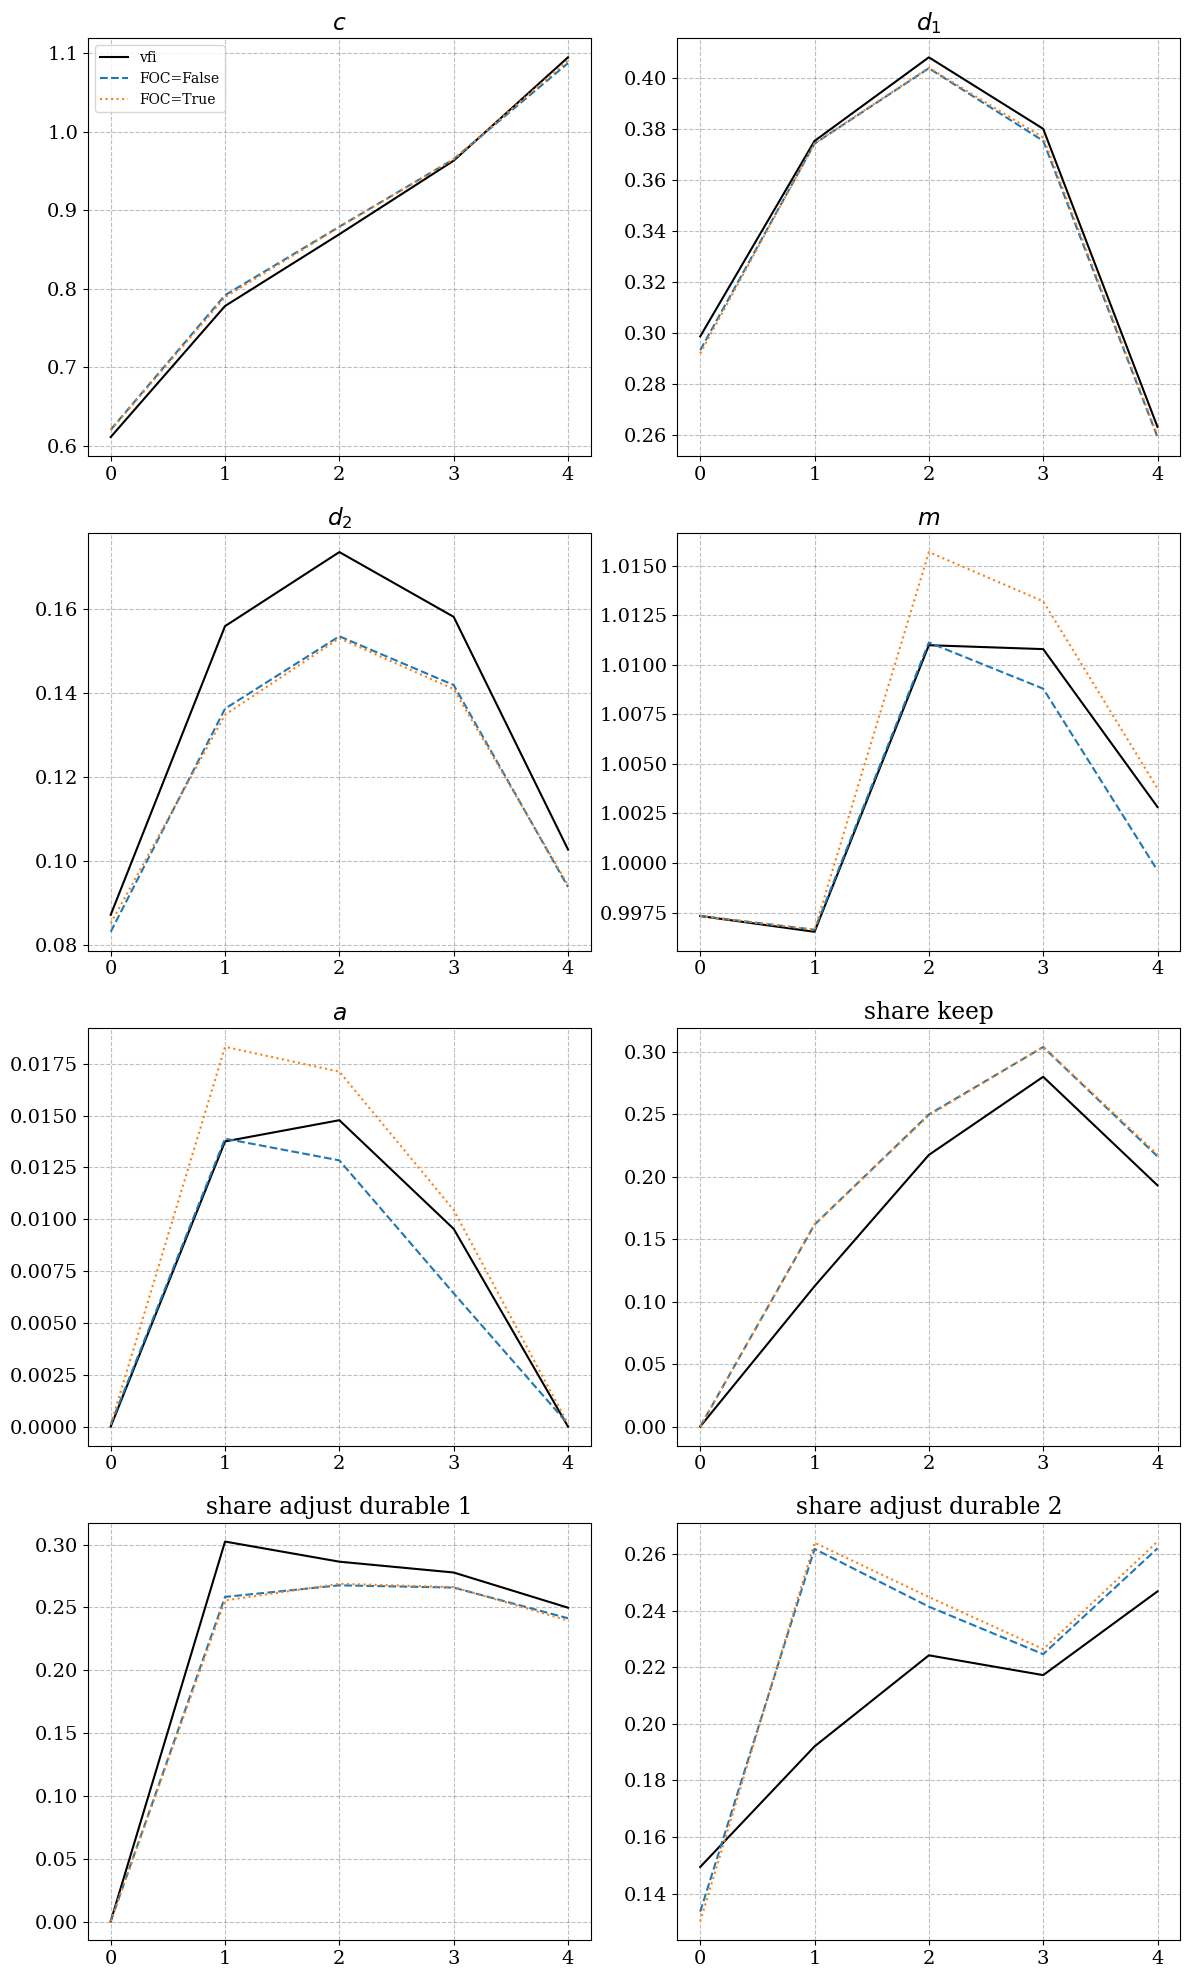

In [9]:
fig = plt.figure(figsize=(12,20))

ax = fig.add_subplot(4,2,1)
if DO_DP: ax.plot(np.mean(model_dp.sim.c,axis=1),label='vfi',color='black',ls='-')
for i,(k,v) in enumerate(models_dl.items()):
    ax.plot(np.mean(v.sim.c.detach().cpu().numpy(),axis=1),label=f'FOC={k}',ls=ls[i],color=colors[i])
ax.set_title('$c$')
ax.legend(loc='upper left',fontsize=10)

ax = fig.add_subplot(4,2,2)
if DO_DP: ax.plot(np.mean(model_dp.sim.d1,axis=1),color='black',ls='-')
for i,(k,v) in enumerate(models_dl.items()):
    ax.plot(np.mean(v.sim.d1.detach().cpu().numpy(),axis=1),label=f'FOC={k}',ls=ls[i],color=colors[i])
ax.set_title('$d_1$')

ax = fig.add_subplot(4,2,3)
if DO_DP: ax.plot(np.mean(model_dp.sim.d2,axis=1),color='black',ls='-')
for i,(k,v) in enumerate(models_dl.items()):
    ax.plot(np.mean(v.sim.d2.detach().cpu().numpy(),axis=1),label=f'FOC={k}',ls=ls[i],color=colors[i])
ax.set_title('$d_2$')

ax = fig.add_subplot(4,2,4)
if DO_DP: ax.plot(np.mean(model_dp.sim.states[...,0],axis=1),color='black',ls='-')
for i,(k,v) in enumerate(models_dl.items()):
    ax.plot(np.mean(v.sim.states[...,0].detach().cpu().numpy(),axis=1),label=f'FOC={k}',ls=ls[i],color=colors[i])
ax.set_title('$m$')

ax = fig.add_subplot(4,2,5)
if DO_DP: ax.plot(np.mean(model_dp.sim.states_pd[...,0],axis=1),color='black',ls='-')
for i,(k,v) in enumerate(models_dl.items()):
    ax.plot(np.mean(v.sim.states_pd[...,0].detach().cpu().numpy(),axis=1),label=f'FOC={k}',ls=ls[i],color=colors[i])
ax.set_title('$a$')

ax = fig.add_subplot(4,2,6)
if DO_DP: ax.plot(np.mean(model_dp.sim.DC == 0,axis=1),color='black',ls='-')
for i,(k,v) in enumerate(models_dl.items()):
    ax.plot(np.mean(v.sim.DC.detach().cpu().numpy() == 0,axis=1),label=f'FOC={k}',ls=ls[i],color=colors[i])
ax.set_title('share keep')

ax = fig.add_subplot(4,2,7)
if DO_DP: ax.plot(np.mean(model_dp.sim.DC == 1, axis=1),color='black',ls='-')
for i,(k,v) in enumerate(models_dl.items()):
    ax.plot(np.mean(v.sim.DC.detach().cpu().numpy() == 1,axis=1),label=f'FOC={k}',ls=ls[i],color=colors[i])
ax.set_title('share adjust durable 1')

ax = fig.add_subplot(4,2,8)
if DO_DP: ax.plot(np.mean(model_dp.sim.DC == 2, axis=1),color='black',ls='-')
for i,(k,v) in enumerate(models_dl.items()):
    ax.plot(np.mean(v.sim.DC.detach().cpu().numpy() == 2,axis=1),label=f'FOC={k}',ls=ls[i],color=colors[i])
ax.set_title('share adjust durable 2')

fig.tight_layout()